In [1]:
# Importing the Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [3]:
# Load the Data
data = pd.read_csv('Heart Disease Prediction.csv')

In [5]:
# Analyse the Top 5 rows of the Data
data.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [11]:
# Education column is irrelevant for our analysis so we will drop this column
data.drop(columns= ['education'], axis = 1, inplace = True)

In [15]:
data.rename(columns={'male':'sex_male'}, inplace = True)

In [19]:
data.isnull().sum()

sex_male             0
age                  0
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [25]:
data.dropna(inplace =  True)

In [29]:
print(data.TenYearCHD.value_counts())

TenYearCHD
0    3179
1     572
Name: count, dtype: int64


#### Splitting the Dataset into Test and Train Sets

In [34]:
X =  np.asarray(data.drop(columns= ['TenYearCHD']))

In [40]:
y = np.asarray(data['TenYearCHD'])

In [42]:
X = preprocessing.StandardScaler().fit(X).transform(X)

In [44]:
from sklearn.model_selection import train_test_split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 42)

In [48]:
print('Train set:', X_train.shape, y_train.shape)

Train set: (2625, 14) (2625,)


In [52]:
print('Test Set:', X_test.shape, y_test.shape)

Test Set: (1126, 14) (1126,)


#### Exploratory Data Analysis of Heart Disease Dataset

C:\Users\irt\AppData\Local\Temp\ipykernel_28200\3948611720.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TenYearCHD', data=data,


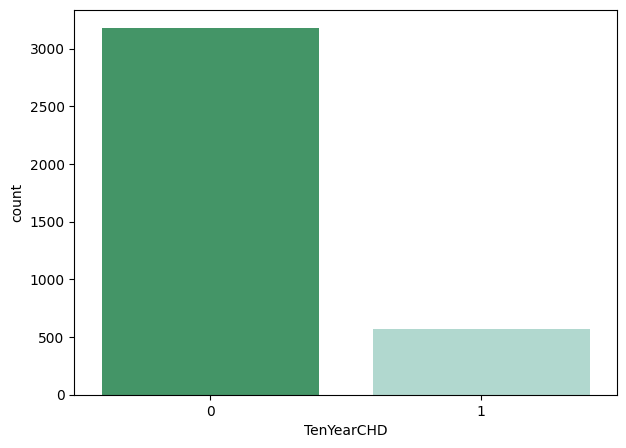

In [55]:
plt.figure(figsize=(7, 5))
sns.countplot(x='TenYearCHD', data=data,
             palette="BuGn_r")
plt.show()

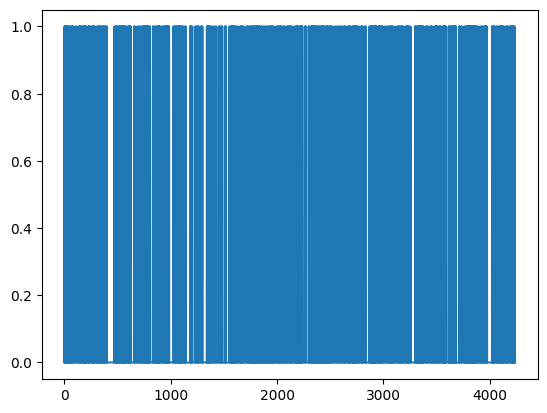

In [57]:
laste = data['TenYearCHD'].plot()
plt.show(laste)

##### - Blue bars: Indicate the absence of heart disease.
##### -  White space (gaps): These represent the presence of heart disease.

#### Fitting Logistic Regression Model for Heart Disease Prediction

In [63]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

#### Evaluating Logistic Regression Model

In [66]:
from sklearn.metrics import accuracy_score
print('Accuracy of the model is =', 
      accuracy_score(y_test, y_pred))

Accuracy of the model is = 0.8339253996447602


The details for confusion matrix is =
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       938
           1       0.52      0.07      0.12       188

    accuracy                           0.83      1126
   macro avg       0.68      0.53      0.52      1126
weighted avg       0.79      0.83      0.78      1126



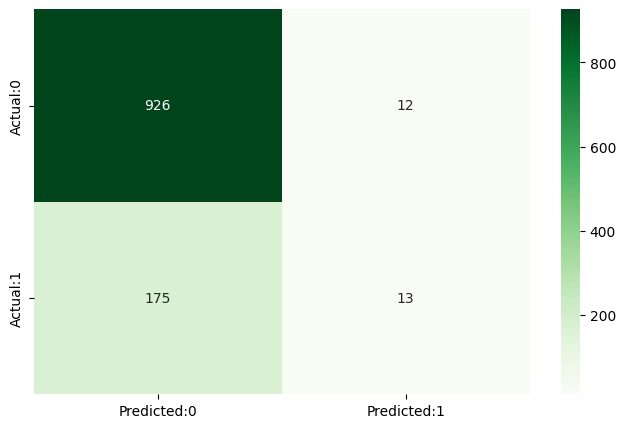

In [68]:
# Plotting Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

print('The details for confusion matrix is =')
print (classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
conf_matrix = pd.DataFrame(data = cm, 
                           columns = ['Predicted:0', 'Predicted:1'], 
                           index =['Actual:0', 'Actual:1'])

plt.figure(figsize = (8, 5))
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = "Greens")

plt.show()